Step 1: Install required packages
Run this in your terminal:

pip install datasets pandas matplotlib seaborn wordcloud

Step 2: Load the dataset & filter English ticket

In [9]:
from datasets import load_dataset
import pandas as pd

# Load from HuggingFace
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")

# Convert to pandas DataFrame
df = pd.DataFrame(dataset['train'])

# Filter only English language tickets
df = df[df['language'] == 'en'].reset_index(drop=True)

print(f"Total English tickets: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

df.to_csv('/Users/aanchala/Downloads/Task4/data/customer_support_tickets_en.csv', index=False)
print("Saved! Shape:", df.shape)

Total English tickets: 28261
Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']
Saved! Shape: (28261, 16)


Step 4: Explore the structure

Next cell — let's understand what we're working with:

In [10]:
# Data types and missing values
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Sample row ---")
df.iloc[0]

subject      object
body         object
answer       object
type         object
queue        object
priority     object
language     object
version     float64
tag_1        object
tag_2        object
tag_3        object
tag_4        object
tag_5        object
tag_6        object
tag_7        object
tag_8        object
dtype: object

--- Missing Values ---
subject      3639
body            1
answer          6
type            0
queue           0
priority        0
language        0
version     11923
tag_1           0
tag_2          16
tag_3         113
tag_4        2584
tag_5       11960
tag_6       20353
tag_7       24562
tag_8       26653
dtype: int64

--- Sample row ---


subject                                    Account Disruption
body        Dear Customer Support Team,\n\nI am writing to...
answer      Thank you for reaching out, <name>. We are awa...
type                                                 Incident
queue                                       Technical Support
priority                                                 high
language                                                   en
version                                                  51.0
tag_1                                                 Account
tag_2                                              Disruption
tag_3                                                  Outage
tag_4                                                      IT
tag_5                                            Tech Support
tag_6                                                    None
tag_7                                                    None
tag_8                                                    None
Name: 0,

Step 4: Basic statistics & text length analysis
the min/max/mean word counts,then moving to category analysis.

       ticket_word_count  ticket_char_count
count       28261.000000       28261.000000
mean           55.352677         371.265843
std            31.249665         202.882721
min             1.000000           4.000000
25%            30.000000         203.000000
50%            54.000000         365.000000
75%            79.000000         533.000000
max           272.000000        1793.000000


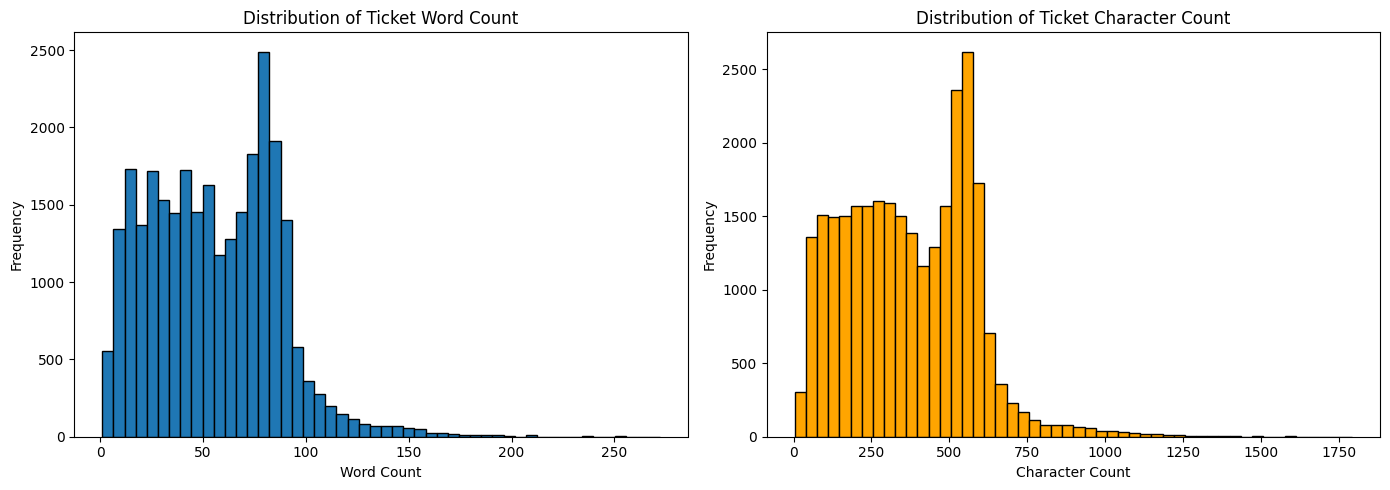

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add text length columns
df['ticket_word_count'] = df['body'].apply(lambda x: len(str(x).split()))
df['ticket_char_count'] = df['body'].apply(lambda x: len(str(x)))

# Summary stats
print(df[['ticket_word_count', 'ticket_char_count']].describe())

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['ticket_word_count'], bins=50, edgecolor='black')
axes[0].set_title('Distribution of Ticket Word Count')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['ticket_char_count'], bins=50, edgecolor='black', color='orange')
axes[1].set_title('Distribution of Ticket Character Count')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Average ~55 words per ticket, right-skewed with most between 20-100 words. Some outliers up to 272 words.

step 5: Category/Label frequency analysis

to know if there's class imbalance across types, queues, and priorities

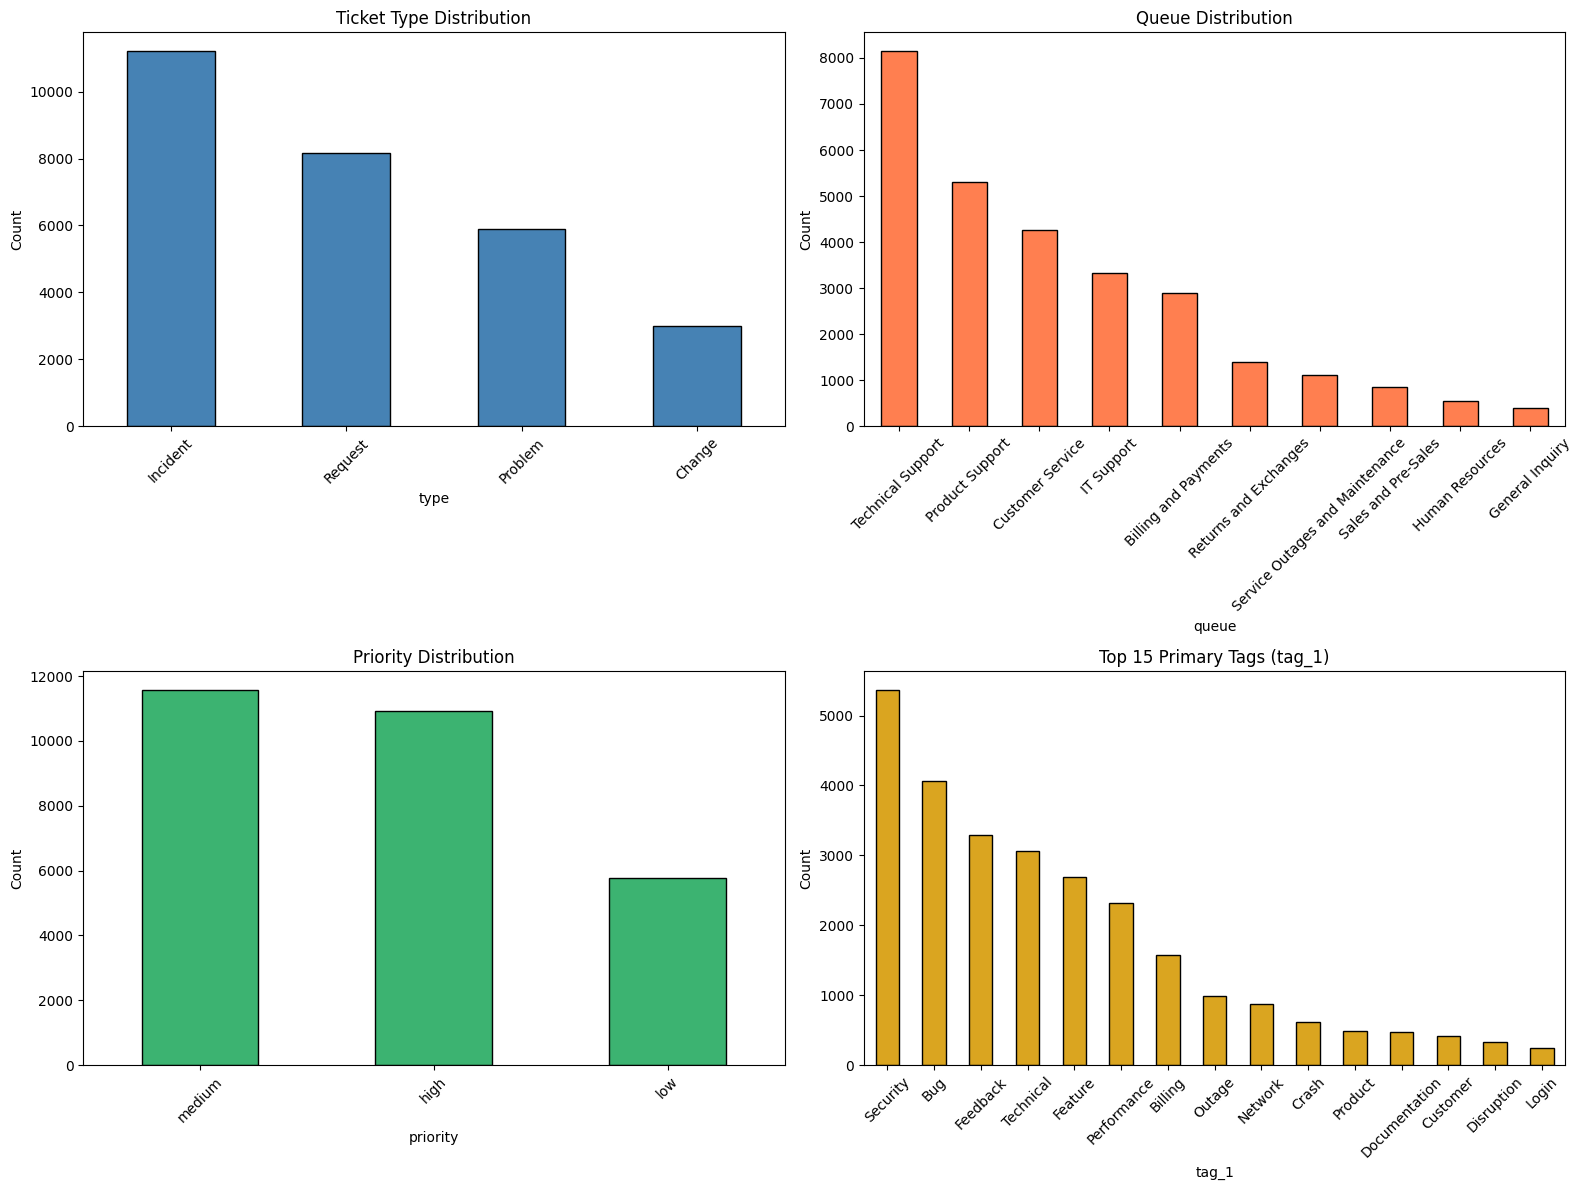

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Ticket Type distribution
df['type'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Ticket Type Distribution')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Queue distribution
df['queue'].value_counts().plot(kind='bar', ax=axes[0, 1], color='coral', edgecolor='black')
axes[0, 1].set_title('Queue Distribution')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Priority distribution
df['priority'].value_counts().plot(kind='bar', ax=axes[1, 0], color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('Priority Distribution')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Tag_1 (primary tag) distribution - top 15
df['tag_1'].value_counts().head(15).plot(kind='bar', ax=axes[1, 1], color='goldenrod', edgecolor='black')
axes[1, 1].set_title('Top 15 Primary Tags (tag_1)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Key observations:
1. Type: Incidents dominate (11K), followed by Requests (8K)
2. Queue: Technical Support is the busiest, then Product Support
3. Priority: Medium & High are roughly equal (11K each), Low is much less (6K)
4. Tags: Security, Bug, Feedback are the top primary tags

step 6: Word frequency analysis & word clouds

the overall vocabulary picture of what customers talk about most



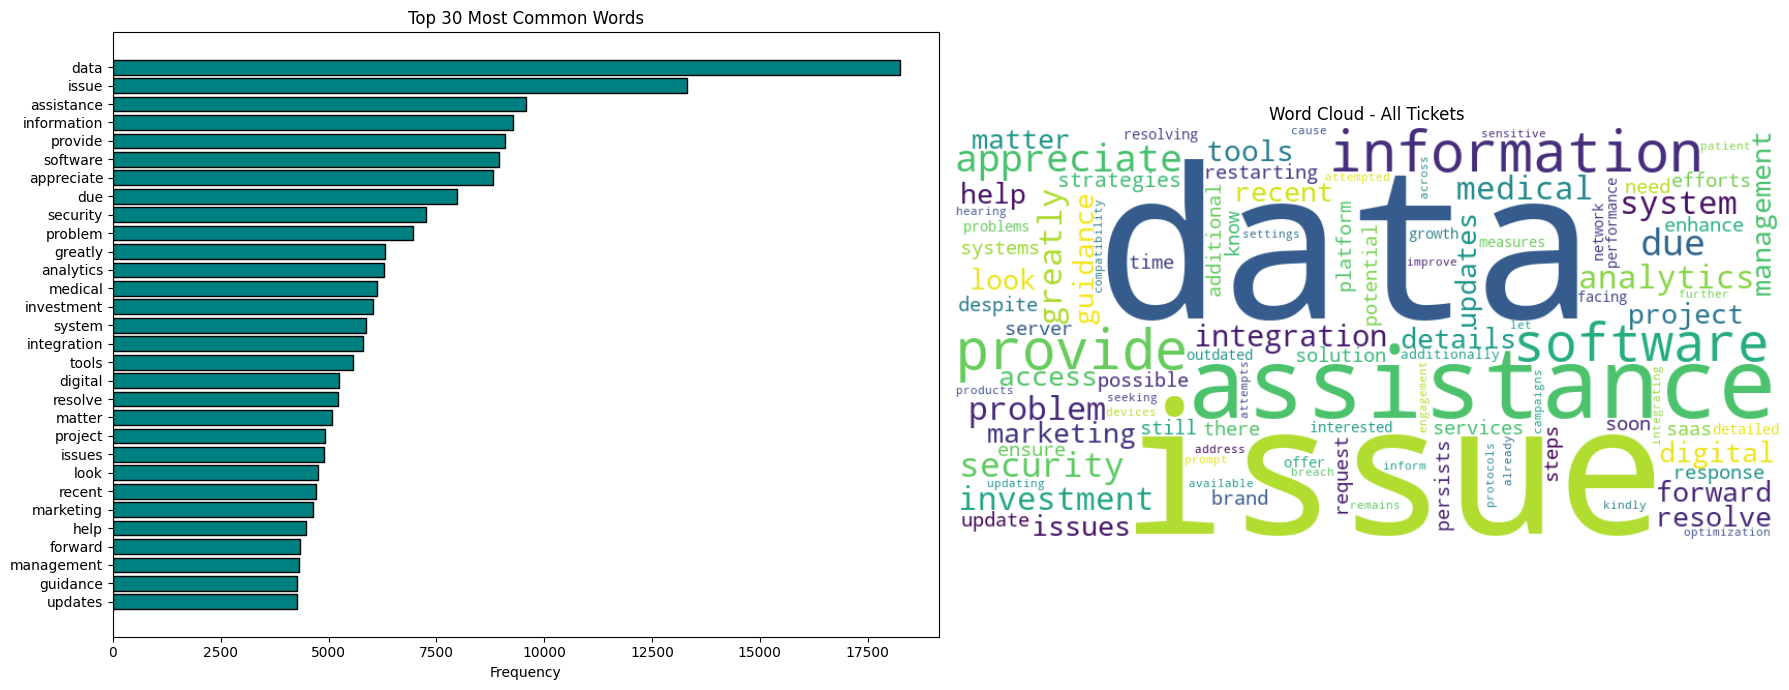

In [13]:
from wordcloud import WordCloud
from collections import Counter
import re

# Basic text cleaning for word frequency
def simple_clean(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    # Remove common stopwords
    stopwords = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
                 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could',
                 'should', 'may', 'might', 'shall', 'can', 'to', 'of', 'in', 'for',
                 'on', 'with', 'at', 'by', 'from', 'as', 'into', 'through', 'during',
                 'before', 'after', 'and', 'but', 'or', 'nor', 'not', 'so', 'yet',
                 'both', 'either', 'neither', 'each', 'every', 'all', 'any', 'few',
                 'more', 'most', 'other', 'some', 'such', 'no', 'only', 'own', 'same',
                 'than', 'too', 'very', 'just', 'because', 'if', 'when', 'where',
                 'how', 'what', 'which', 'who', 'whom', 'this', 'that', 'these',
                 'those', 'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'you',
                 'your', 'he', 'him', 'his', 'she', 'her', 'it', 'its', 'they',
                 'them', 'their', 'am', 'about', 'up', 'out', 'also', 'please',
                 'dear', 'team', 'support', 'customer', 'hello', 'hi', 'regards',
                 'thank', 'thanks', 'hope', 'message', 'writing', 'like', 'well',
                 'reach', 'reaching', 'find', 'finds'}
    return [w for w in words if w not in stopwords and len(w) > 2]

# Get all words
all_words = []
for text in df['body']:
    all_words.extend(simple_clean(text))

word_freq = Counter(all_words)

# Top 30 most common words
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart of top 30 words
top_30 = word_freq.most_common(30)
words, counts = zip(*top_30)
axes[0].barh(list(reversed(words)), list(reversed(counts)), color='teal', edgecolor='black')
axes[0].set_title('Top 30 Most Common Words')
axes[0].set_xlabel('Frequency')

# Word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      max_words=100, colormap='viridis').generate_from_frequencies(word_freq)
axes[1].imshow(wordcloud, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud - All Tickets')

plt.tight_layout()
plt.show()

most used: "data", "issue", "assistance", "information", "software", "security" 

Step 7:  Cross-tabulation — Type vs Priority & Tag analysis
it shows how type relates to priority, how verbose each ticket type is, and how sparse the tag columns get

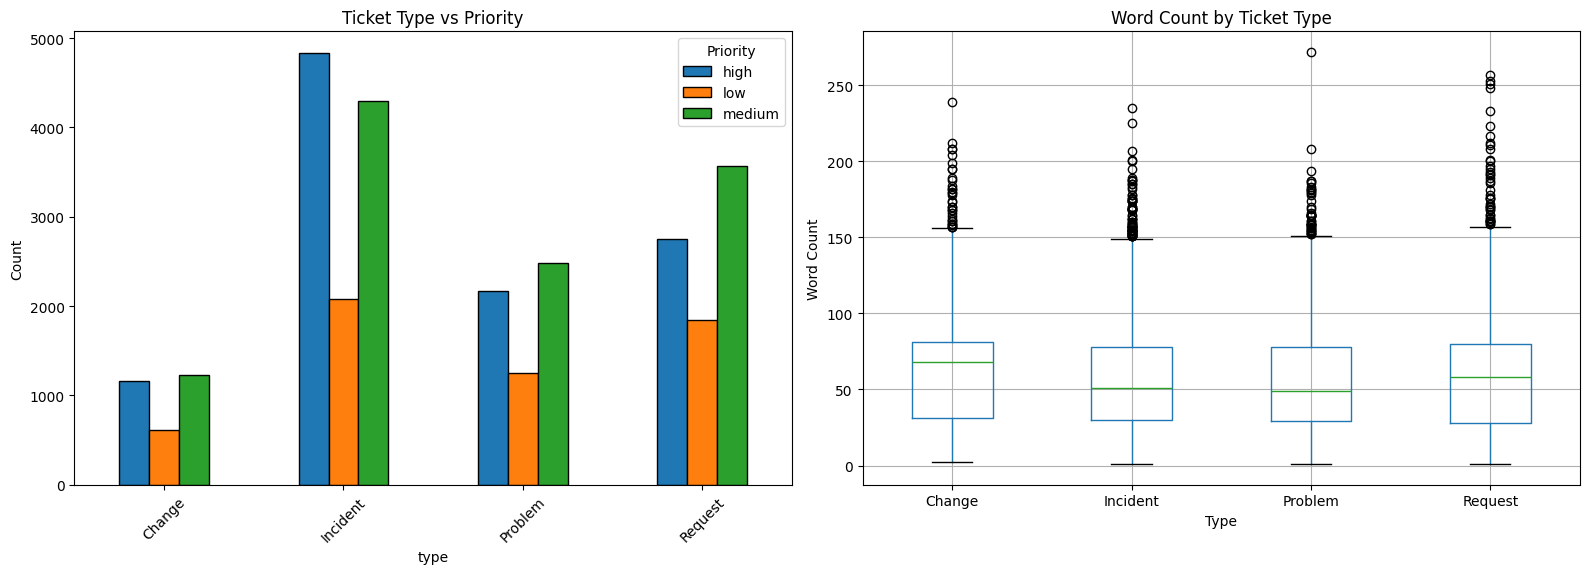


--- Missing values in tag columns ---
tag_1: 0 missing/None (0.0%)
tag_2: 16 missing/None (0.1%)
tag_3: 113 missing/None (0.4%)
tag_4: 2584 missing/None (9.1%)
tag_5: 11960 missing/None (42.3%)
tag_6: 20353 missing/None (72.0%)
tag_7: 24562 missing/None (86.9%)
tag_8: 26653 missing/None (94.3%)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Type vs Priority crosstab
ct = pd.crosstab(df['type'], df['priority'])
ct.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Ticket Type vs Priority')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Priority')

# Word count by ticket type (boxplot)
df.boxplot(column='ticket_word_count', by='type', ax=axes[1])
axes[1].set_title('Word Count by Ticket Type')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.show()

# Quick summary stats
print("\n--- Missing values in tag columns ---")
for col in ['tag_1','tag_2','tag_3','tag_4','tag_5','tag_6','tag_7','tag_8']:
    none_count = (df[col] == 'None').sum() + df[col].isnull().sum()
    print(f"{col}: {none_count} missing/None ({none_count/len(df)*100:.1f}%)")

Inference: 

## EDA Summary

### Dataset Overview
- **Source**: HuggingFace (`Tobi-Bueck/customer-support-tickets`)
- **Total tickets**: 61,765 | **English only**: 28,261
- **Columns**: 16 (subject, body, answer, type, queue, priority, language, version, tag_1 to tag_8)

### Key Findings

**1. Text Statistics**
- Average ticket length: ~55 words (371 chars)
- Most tickets fall between 20-100 words
- Right-skewed distribution with outliers up to 272 words
- Word count is similar across all ticket types (median ~50-65)

**2. Category Distributions**
- **Type**: Incidents dominate (~11K), followed by Requests (~8K), Problems (~6K), Changes (~3K)
- **Queue**: Technical Support is busiest (~8K), then Product Support (~5.5K), Customer Service (~4.3K)
- **Priority**: Medium (~11.5K) and High (~11K) are roughly equal; Low is underrepresented (~6K)
- Incidents tend to be high priority; Requests are more evenly distributed

**3. Tag Analysis**
- tag_1 to tag_3 are well populated (>99% filled)
- Tags become very sparse beyond tag_4 — tag_8 is 94.3% empty
- **Top primary tags**: Security, Bug, Feedback, Technical, Feature, Performance, Billing
- For analysis, we should focus on tag_1 to tag_3 only

**4. Most Frequent Words**
- Dominant terms: "data", "issue", "assistance", "information", "software", "security"
- Suggests a tech/software-focused customer base
- Common themes: data-related issues, security concerns, software problems, integration requests

### Data Quality Notes
- No missing values in core columns (body, type, queue, priority)
- Tag columns get progressively sparser (tag_5 onwards mostly empty)
- Some tickets are very short (min 1 word) — may need filtering during preprocessing

### Implications for Next Steps
- Text is relatively short — sentence embeddings may work better than TF-IDF for capturing meaning
- Security & Bug are the most common issue categories — our topic models should surface these
- Class imbalance in type/priority — worth considering during evaluation